In [ ]:
pip install opendatasets

In [ ]:
import opendatasets as od
od.download('https://www.kaggle.com/datasets/shivendratomar/e-commerce-basic-eda')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: shivendratomar
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/shivendratomar/e-commerce-basic-eda


100%|██████████| 146M/146M [00:01<00:00, 131MB/s]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
final_df=pd.read_csv('/content/e-commerce-basic-eda/Final_Cleaned_Dataset_with_sorting.csv')

In [ ]:
# Convert text to actual Date-Time object
final_df['event_time'] = pd.to_datetime(final_df['event_time'])
# Missing brands ko ek category bana do taaki nunique() sahi se kaam kare
final_df['brand_filled'] = final_df['brand_filled'].fillna('unknown_brand')

In [ ]:
import numpy as np
import pandas as pd
from IPython.display import display

print("⏳ INITIATING FULL REAL-TIME SNAPSHOT PIPELINE (Cleaning + Feature Engineering)...")

# ==========================================
# STEP 1: DATA CLEANING (Remove Bots & Bounces)
# ==========================================
print("🧹 1. Cleaning Bots and Accidental Bouncers...")
session_stats = final_df.groupby('user_session').agg(
    start_time=('event_time', 'min'),
    end_time=('event_time', 'max'),
    total_events=('event_type', 'count')
).reset_index()

session_stats['total_duration_sec'] = (session_stats['end_time'] - session_stats['start_time']).dt.total_seconds()

# Filters
bounce_condition = (session_stats['total_events'] == 1) | (session_stats['total_duration_sec'] < 5)
views_per_minute = session_stats['total_events'] / ((session_stats['total_duration_sec'] + 1) / 60)
bot_condition = (views_per_minute > 30) & (session_stats['total_events'] > 15)

# Extract only valid human sessions
valid_sessions = session_stats[~(bounce_condition | bot_condition)]['user_session']
clean_df = final_df[final_df['user_session'].isin(valid_sessions)].copy()

print(f"✅ Data Cleaned! Kept {len(valid_sessions):,} Valid Human Sessions out of {len(session_stats):,}.")

final_df = clean_df  # Purane final_df ko saaf data se overwrite kar diya
del clean_df         # Extra variable ko delete kar diya
import gc
gc.collect()         # Python ko bola ki RAM turant free (flush) kar de!

⏳ INITIATING FULL REAL-TIME SNAPSHOT PIPELINE (Cleaning + Feature Engineering)...
🧹 1. Cleaning Bots and Accidental Bouncers...
✅ Data Cleaned! Kept 871,859 Valid Human Sessions out of 1,378,222.


55

In [ ]:

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_curve, auc,
    f1_score, recall_score, precision_score, roc_auc_score,
    precision_recall_curve, average_precision_score
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, GRU, Dense, Dropout, Masking,
    BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.sequence import pad_sequences

# GPU Configuration
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'✅ GPU Active: {[g.name for g in gpus]}')
    except RuntimeError as e:
        print(f'GPU config error: {e}')
else:
    print('⚠️ No GPU found — running on CPU')

sns.set_theme(style='whitegrid')
GRU_OUTPUT_DIR = 'output_Pure_GRU'
os.makedirs(GRU_OUTPUT_DIR, exist_ok=True)

✅ GPU Active: ['/physical_device:GPU:0']


### Cell 2: Data Prep & Zero-Leakage Sequence Generation

In [ ]:

# %%
print('='*65)
print('⚙️ BUILDING ZERO-LEAKAGE GRU SEQUENCES')
print('='*65)

# 1. Define global targets FIRST (Did this session EVER have a purchase?)
session_targets = (
    final_df.groupby('user_session')['event_type']
    .apply(lambda x: 1 if 'purchase' in x.values else 0)
    .to_dict()
)

print(f"Total Buyers found: {sum(session_targets.values()):,}")

# 🚨 2. THE ANTI-LEAKAGE BARRIER 🚨
# Remove all 'purchase' AND 'cart' events. The model will only see 'view' events!
seq_df = final_df[~final_df['event_type'].isin(['purchase', 'cart'])].copy()

# Sort chronologically to make valid time sequences
seq_df = seq_df.sort_values(by=['user_session', 'event_time'])

# 3. Feature Engineering for the Sequence
# Price scaling
seq_df['log_price']    = np.log1p(seq_df['price'])
price_scaler           = MinMaxScaler()
seq_df['scaled_price'] = price_scaler.fit_transform(seq_df[['log_price']])

# Time Gap (How long did they look at the previous item before this one?)
seq_df['time_gap_seconds'] = (
    seq_df.groupby('user_session')['event_time']
    .diff().dt.total_seconds().fillna(0)
)
seq_df['log_time_gap'] = np.log1p(seq_df['time_gap_seconds'])

# Since we only have views left, we only need Price and Time metrics
sequence_features = ['scaled_price', 'log_time_gap']

# 4. Group into lists for Keras
print("Grouping events into sequences...")
session_groups = (
    seq_df.groupby('user_session')[sequence_features]
    .apply(lambda x: x.values.tolist())
)

# Align Targets with valid sessions that actually have views
gru_session_ids = np.array(session_groups.index)
gru_y           = np.array([session_targets[s] for s in gru_session_ids])

# 5. Padding (Limit to last 15 views to focus on most recent intent)
MAX_STEPS = 15
gru_X = pad_sequences(
    session_groups.tolist(),
    maxlen=MAX_STEPS,
    padding='post',     # Add zeros at the end if shorter than 15
    truncating='pre',   # Keep the most recent 15 events if longer
    dtype='float32'
)

gru_X = np.nan_to_num(gru_X.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
gru_y = gru_y.astype(np.float32)

print(f'\n✅ Final GRU Input Shape : {gru_X.shape} -> (Sessions, Time_Steps, Features)')
print(f'✅ Final Target Shape    : {gru_y.shape}')

# 6. Train/Test Split
gru_X_train, gru_X_test, gru_y_train, gru_y_test = train_test_split(
    gru_X, gru_y, test_size=0.2, random_state=42, stratify=gru_y
)

# Handle extreme imbalance using class weights
neg_count = (gru_y_train == 0).sum()
pos_count = (gru_y_train == 1).sum()
class_weight_dict = {0: 1.0, 1: float(neg_count / pos_count)}

print(f'\nTraining sequences: {len(gru_X_train):,}')
print(f'Testing sequences : {len(gru_X_test):,}')
print(f'Class Weight for Buyer (Class 1) : {class_weight_dict[1]:.2f}')

⚙️ BUILDING ZERO-LEAKAGE GRU SEQUENCES
Total Buyers found: 77,118
Grouping events into sequences...

✅ Final GRU Input Shape : (871569, 15, 2) -> (Sessions, Time_Steps, Features)
✅ Final Target Shape    : (871569,)

Training sequences: 697,255
Testing sequences : 174,314
Class Weight for Buyer (Class 1) : 10.34


#### Cell 3: Building the Anti-Overfit GRU

In [ ]:

# ## Step 2: Architecture & Training
# Deep GRU with high dropout and regularizers to prevent memorization.

# %%
inputs = Input(shape=(MAX_STEPS, 2), name='sequence_input')

# Masking tells the network to ignore the padded 0s
x = Masking(mask_value=0.0)(inputs)

# Layer 1: Detect fast/slow scrolling patterns
x = GRU(
    64, return_sequences=True, activation='tanh',
    recurrent_dropout=0.2, kernel_regularizer=l2(1e-4), name='gru_layer_1'
)(x)
x = BatchNormalization()(x)

# Layer 2: Final session fingerprint
x = GRU(
    32, return_sequences=False, activation='tanh',
    recurrent_dropout=0.2, kernel_regularizer=l2(1e-4), name='gru_layer_2'
)(x)
x = BatchNormalization()(x)

# Dense Classification Head
x      = Dropout(0.5)(x)
x      = Dense(32, activation='relu', kernel_regularizer=l2(1e-4))(x)
x      = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid', name='intent_prediction')(x)

gru_model = Model(inputs=inputs, outputs=output)

gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', curve='PR')] # Optimizing for PR-AUC
)

gru_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 15, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 15, 2)     │          0 │ sequence_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 15, 2)     │          0 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 15)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_layer_1 (GRU)   │ (None, 15, 64)    │     13,056 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 15, 64)    │        256 │ gru_layer_1[0][0… │
│ (BatchNormalizatio… │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_layer_2 (GRU)   │ (None, 32)        │      9,408 │ batch_normalizat… │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ gru_layer_2[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      1,056 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ intent_prediction   │ (None, 1)         │         33 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,937 (93.50 KB)

 Trainable params: 23,745 (92.75 KB)

 Non-trainable params: 192 (768.00 B)

## Cell 4: Training Execution

In [ ]:

# ## Step 3: Run Training with Callbacks

# %%
callbacks = [
    ModelCheckpoint(
        filepath=os.path.join(GRU_OUTPUT_DIR, 'best_gru_model.keras'),
        monitor='val_auc', mode='max', save_best_only=True, verbose=1
    ),
    EarlyStopping(
        monitor='val_auc', mode='max', patience=5, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc', mode='max', factor=0.5, patience=2, min_lr=1e-5, verbose=1
    )
]

print('\n🚀 Starting GRU Training...')
t0 = time.time()

gru_history = gru_model.fit(
    gru_X_train, gru_y_train,
    epochs=25,
    batch_size=512,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print(f'\n✅ Training Completed in {(time.time()-t0)/60:.1f} minutes')


🚀 Starting GRU Training...
Epoch 1/25
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5821 - auc: 0.1608 - loss: 1.2725
Epoch 1: val_auc improved from None to 0.24428, saving model to output_Pure_GRU/best_gru_model.keras

Epoch 1: finished saving model to output_Pure_GRU/best_gru_model.keras
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 142s 111ms/step - accuracy: 0.6199 - auc: 0.1876 - loss: 1.2062 - val_accuracy: 0.6095 - val_auc: 0.2443 - val_loss: 0.6182 - learning_rate: 0.0010
Epoch 2/25
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.6499 - auc: 0.2283 - loss: 1.1560
Epoch 2: val_auc improved from 0.24428 to 0.24659, saving model to output_Pure_GRU/best_gru_model.keras

Epoch 2: finished saving model to output_Pure_GRU/best_gru_model.keras
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 130s 108ms/step - accuracy: 0.6579 - auc: 0.2287 - loss: 1.1482 - val_accuracy: 0.6324 - val_auc: 0.2466 - val_loss: 0.6246 - learning_rate: 0.0010
Epoch 3/25
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step -

#### Cell 5: Full Evaluation & Matrix Calculation

📊 FINAL GRU EVALUATION
171/171 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step
Optimal Threshold (F2) : 0.5249
ROC-AUC Score          : 0.7934
PR-AUC Score           : 0.3068
Accuracy               : 73.17%
Precision (Class 1)    : 20.65%
Recall (Class 1)       : 71.78%
F1-Score (Class 1)     : 32.07%

📋 Classification Report:
                precision    recall  f1-score   support

Window Shopper       0.96      0.73      0.83    158937
    True Buyer       0.21      0.72      0.32     15377

      accuracy                           0.73    174314
     macro avg       0.59      0.73      0.58    174314
  weighted avg       0.90      0.73      0.79    174314



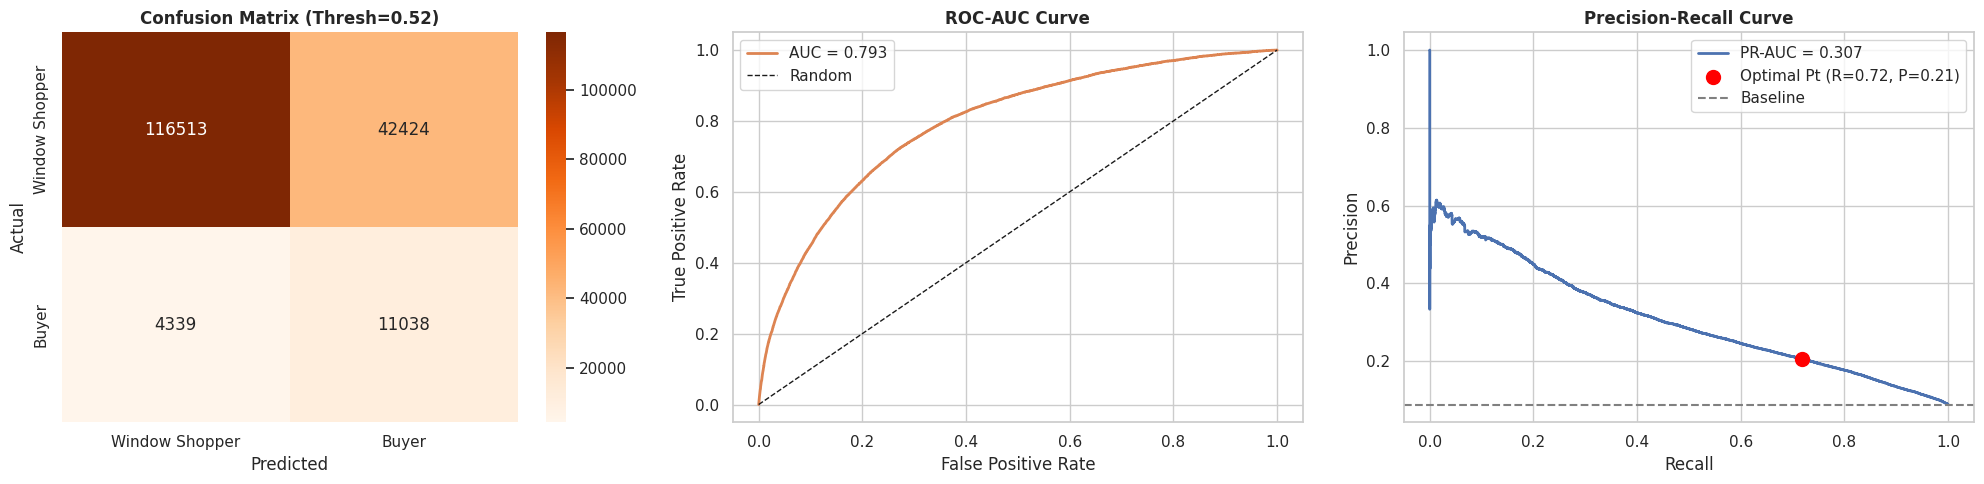

In [ ]:

# %%
print('='*65)
print('📊 FINAL GRU EVALUATION')
print('='*65)

# Predict Probabilities
gru_y_probs = gru_model.predict(gru_X_test, batch_size=1024).flatten()

# Find Optimal F2 Threshold (Prioritizing Early Buyers)
precisions, recalls, thresholds = precision_recall_curve(gru_y_test, gru_y_probs)
beta = 2 # F2 favors recall
f2_scores = np.where(
    (beta**2 * precisions + recalls) > 0,
    (1 + beta**2) * precisions * recalls / (beta**2 * precisions + recalls),
    0
)
best_thresh_idx = np.argmax(f2_scores[:-1])
best_thresh = thresholds[best_thresh_idx]

# Final Predictions using the Optimal Threshold
gru_y_pred = (gru_y_probs >= best_thresh).astype(int)

# --- CALCULATE ALL MATRICES ---
roc_auc = roc_auc_score(gru_y_test, gru_y_probs)
pr_auc  = average_precision_score(gru_y_test, gru_y_probs)
acc     = accuracy_score(gru_y_test, gru_y_pred)
prec    = precision_score(gru_y_test, gru_y_pred)
rec     = recall_score(gru_y_test, gru_y_pred)
f1      = f1_score(gru_y_test, gru_y_pred)

print(f"Optimal Threshold (F2) : {best_thresh:.4f}")
print(f"ROC-AUC Score          : {roc_auc:.4f}")
print(f"PR-AUC Score           : {pr_auc:.4f}")
print(f"Accuracy               : {acc*100:.2f}%")
print(f"Precision (Class 1)    : {prec*100:.2f}%")
print(f"Recall (Class 1)       : {rec*100:.2f}%")
print(f"F1-Score (Class 1)     : {f1*100:.2f}%")
print("\n📋 Classification Report:")
print(classification_report(gru_y_test, gru_y_pred, target_names=['Window Shopper', 'True Buyer']))

# --- PLOTTING ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Confusion Matrix
cm = confusion_matrix(gru_y_test, gru_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Window Shopper', 'Buyer'],
            yticklabels=['Window Shopper', 'Buyer'], ax=axes[0])
axes[0].set_title(f'Confusion Matrix (Thresh={best_thresh:.2f})', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(gru_y_test, gru_y_probs)
axes[1].plot(fpr, tpr, color='#DD8452', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0,1],[0,1],'k--',lw=1,label='Random')
axes[1].set_title('ROC-AUC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# 3. Precision-Recall Curve
axes[2].plot(recalls, precisions, color='#4C72B0', lw=2, label=f'PR-AUC = {pr_auc:.3f}')
axes[2].scatter(rec, prec, color='red', s=100, zorder=5, label=f'Optimal Pt (R={rec:.2f}, P={prec:.2f})')
axes[2].axhline(y=(gru_y_test==1).mean(), color='gray', linestyle='--', label='Baseline')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:

# # Pure GRU Pre-Cart Purchase Intent Model & Extractor Setup
# **Objective:** Train the GRU on behavioral sequences and save the 32-dim Extractor.

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, time, pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_auc_score, precision_recall_curve, average_precision_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, GRU, Dense, Dropout, Masking, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.sequence import pad_sequences

# =============================================================================
# SETUP & GPU CONFIG
# =============================================================================
GRU_OUTPUT_DIR = 'output_Pure_GRU'
os.makedirs(GRU_OUTPUT_DIR, exist_ok=True)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'✅ GPU Active: {[g.name for g in gpus]}')
    except RuntimeError as e:
        print(f'GPU config error: {e}')
else:
    print('⚠️ No GPU found — running on CPU')

print('\n' + '='*65)
print('⚙️ STEP 1: BUILDING ZERO-LEAKAGE GRU SEQUENCES')
print('='*65)

# 1. Define global targets FIRST (Did this session EVER have a purchase?)
session_targets = (
    final_df.groupby('user_session')['event_type']
    .apply(lambda x: 1 if 'purchase' in x.values else 0)
    .to_dict()
)
print(f"Total Buyers found in dataset: {sum(session_targets.values()):,}")

# 🚨 2. THE ANTI-LEAKAGE BARRIER 🚨
# Remove all 'purchase' AND 'cart' events. The model will only see 'view' events!
seq_df = final_df[~final_df['event_type'].isin(['purchase', 'cart'])].copy()
seq_df = seq_df.sort_values(by=['user_session', 'event_time'])

# 3. Feature Engineering for the Sequence
seq_df['log_price'] = np.log1p(seq_df['price'])
price_scaler = MinMaxScaler()
seq_df['scaled_price'] = price_scaler.fit_transform(seq_df[['log_price']])

# 💾 IMPORTANT: Save the scaler so we can use it during Hybrid inference later!
with open(os.path.join(GRU_OUTPUT_DIR, 'gru_price_scaler.pkl'), 'wb') as f:
    pickle.dump(price_scaler, f)

seq_df['time_gap_seconds'] = seq_df.groupby('user_session')['event_time'].diff().dt.total_seconds().fillna(0)
seq_df['log_time_gap'] = np.log1p(seq_df['time_gap_seconds'])

# Since we only have views left, we only need Price and Time metrics
sequence_features = ['scaled_price', 'log_time_gap']

# 4. Group into lists for Keras
print("Grouping events into sequences...")
session_groups = seq_df.groupby('user_session')[sequence_features].apply(lambda x: x.values.tolist())

gru_session_ids = np.array(session_groups.index)
gru_y = np.array([session_targets[s] for s in gru_session_ids])

# 5. Padding (Limit to last 15 views)
MAX_STEPS = 15
gru_X = pad_sequences(
    session_groups.tolist(),
    maxlen=MAX_STEPS,
    padding='post',
    truncating='pre',
    dtype='float32'
)
gru_X = np.nan_to_num(gru_X.astype(np.float32), nan=0.0)
gru_y = gru_y.astype(np.float32)

print(f'✅ Final GRU Input Shape : {gru_X.shape}')

# 6. Train/Test Split
gru_X_train, gru_X_test, gru_y_train, gru_y_test = train_test_split(
    gru_X, gru_y, test_size=0.2, random_state=42, stratify=gru_y
)

neg_count = (gru_y_train == 0).sum()
pos_count = (gru_y_train == 1).sum()
class_weight_dict = {0: 1.0, 1: float(neg_count / pos_count)}
print(f'Class Weight for Buyer (Class 1) : {class_weight_dict[1]:.2f}')


print('\n' + '='*65)
print('🧠 STEP 2: ARCHITECTURE & TRAINING')
print('='*65)

inputs = Input(shape=(MAX_STEPS, 2), name='sequence_input')
x = Masking(mask_value=0.0)(inputs)

# Layer 1: Detect fast/slow scrolling patterns
x = GRU(64, return_sequences=True, activation='tanh', recurrent_dropout=0.2,
        kernel_regularizer=l2(1e-4), name='gru_layer_1')(x)
x = BatchNormalization()(x)

# Layer 2: Final session fingerprint (THIS IS WHAT WE WILL EXTRACT)
x = GRU(32, return_sequences=False, activation='tanh', recurrent_dropout=0.2,
        kernel_regularizer=l2(1e-4), name='gru_layer_2')(x)
x = BatchNormalization()(x)

# Dense Classification Head
x = Dropout(0.5)(x)
x = Dense(32, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid', name='intent_prediction')(x)

gru_model = Model(inputs=inputs, outputs=output)

gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', curve='PR')]
)

callbacks = [
    ModelCheckpoint(filepath=os.path.join(GRU_OUTPUT_DIR, 'best_gru_model.keras'),
                    monitor='val_auc', mode='max', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=2, min_lr=1e-5, verbose=1)
]

print('\n🚀 Starting GRU Training...')
t0 = time.time()
gru_history = gru_model.fit(
    gru_X_train, gru_y_train,
    epochs=25,
    batch_size=512,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)
print(f'\n✅ Training Completed in {(time.time()-t0)/60:.1f} minutes')


print('\n' + '='*65)
print('💾 STEP 3: CREATING & SAVING THE EMBEDDING EXTRACTOR')
print('='*65)

# Slice the model to stop at 'gru_layer_2'
embedding_extractor = Model(
    inputs=gru_model.input,
    outputs=gru_model.get_layer('gru_layer_2').output,
    name='GRU_Embedding_Extractor'
)

# Freeze the weights so it acts purely as a feature extractor
embedding_extractor.trainable = False

# Save it permanently to disk
extractor_path = os.path.join(GRU_OUTPUT_DIR, 'gru_embedding_extractor.keras')
embedding_extractor.save(extractor_path)

print(f"🎉 SUCCESS! Extractor saved permanently at: {extractor_path}")
print("Now you can load it anytime using: load_model('output_Pure_GRU/gru_embedding_extractor.keras')")

✅ GPU Active: ['/physical_device:GPU:0']

⚙️ STEP 1: BUILDING ZERO-LEAKAGE GRU SEQUENCES
Total Buyers found in dataset: 77,118
Grouping events into sequences...
✅ Final GRU Input Shape : (871569, 15, 2)
Class Weight for Buyer (Class 1) : 10.34

🧠 STEP 2: ARCHITECTURE & TRAINING

🚀 Starting GRU Training...
Epoch 1/25
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.6358 - auc: 0.1663 - loss: 1.3006
Epoch 1: val_auc improved from None to 0.24211, saving model to output_Pure_GRU/best_gru_model.keras

Epoch 1: finished saving model to output_Pure_GRU/best_gru_model.keras
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 128s 107ms/step - accuracy: 0.6269 - auc: 0.1946 - loss: 1.2126 - val_accuracy: 0.5647 - val_auc: 0.2421 - val_loss: 0.6520 - learning_rate: 0.0010
Epoch 2/25
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.6320 - auc: 0.2259 - loss: 1.1540
Epoch 2: val_auc improved from 0.24211 to 0.24484, saving model to output_Pure_GRU/best_gru_model.keras

Epoch 2: finished saving mode

In [ ]:
final_df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_code_filled,brand_filled,hour
1,2019-11-01 19:06:53+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
2,2019-11-01 19:07:11+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
3,2019-11-01 19:08:13+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19
4,2019-11-01 19:09:55+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19
5,2019-11-01 19:11:13+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19
...,...,...,...,...,...,...,...,...,...,...,...,...
6727443,2019-11-16 19:03:20+00:00,view,6501081,2053013554155487563,computers.components.motherboard,gigabyte,45.05,570721322,ffffb9ea-87d1-4f3d-b107-91b1bb087d36,computers.components.motherboard,gigabyte,19
6727444,2019-11-16 19:03:39+00:00,view,6500828,2053013554155487563,computers.components.motherboard,asus,80.06,570721322,ffffb9ea-87d1-4f3d-b107-91b1bb087d36,computers.components.motherboard,asus,19
6727445,2019-11-16 19:03:58+00:00,view,6500974,2053013554155487563,computers.components.motherboard,asrock,82.11,570721322,ffffb9ea-87d1-4f3d-b107-91b1bb087d36,computers.components.motherboard,asrock,19
6727446,2019-11-16 19:06:10+00:00,view,6600378,2053013554189041997,computers.components.memory,geil,32.15,570721322,ffffb9ea-87d1-4f3d-b107-91b1bb087d36,computers.components.memory,geil,19


#### Embeddings:-

In [ ]:
import os
from tensorflow.keras.models import load_model

# 1. Define the directory where you saved it
GRU_OUTPUT_DIR = 'output_Pure_GRU'
extractor_path = os.path.join(GRU_OUTPUT_DIR, 'gru_embedding_extractor.keras')

# 2. Load the embedding extractor
print("⏳ Loading GRU Embedding Extractor...")
embedding_extractor = load_model(extractor_path)
print("✅ Extractor Loaded Successfully!")

# 3. Optional: Verify the architecture (It should end at your 32-dim layer)
embedding_extractor.summary()

⏳ Loading GRU Embedding Extractor...
✅ Extractor Loaded Successfully!


Model: "GRU_Embedding_Extractor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 15, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 15, 2)     │          0 │ sequence_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 15, 2)     │          0 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 15)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_layer_1 (GRU)   │ (None, 15, 64)    │     13,056 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 15, 64)    │        256 │ gru_layer_1[0][0… │
│ (BatchNormalizatio… │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_layer_2 (GRU)   │ (None, 32)        │      9,408 │ batch_normalizat… │
│                     │                   │            │ any[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,720 (88.75 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 22,720 (88.75 KB)

In [ ]:

import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from IPython.display import display
import pickle

print("⚙️ STEP 1: PRE-PROCESSING RAW final_df...")

# 1. Create a working copy
clean_df = final_df.copy()

# 2. Extract Category 1 (Snapshot loop needs 'category_1')
clean_df['category_code'] = clean_df['category_code'].fillna('UNKNOWN')
categories = clean_df['category_code'].str.split('.', n=2, expand=True)
clean_df['category_1'] = categories[0]

# 3. Create target flags and actions
clean_df['is_view'] = (clean_df['event_type'] == 'view').astype(np.int8)
clean_df['is_cart'] = (clean_df['event_type'] == 'cart').astype(np.int8)
clean_df['is_purchase'] = (clean_df['event_type'] == 'purchase').astype(np.int8)

# Mark which sessions eventually convert
purchase_sessions = set(clean_df[clean_df['event_type'] == 'purchase']['user_session'])
clean_df['target_purchase'] = clean_df['user_session'].isin(purchase_sessions).astype(np.int8)

# 4. 🔥 THE FIX: Calculate 'event_offset_seconds' 🔥
clean_df = clean_df.sort_values(by=['user_session', 'event_time'])
clean_df['session_start_time'] = clean_df.groupby('user_session')['event_time'].transform('min')
clean_df['event_offset_seconds'] = (clean_df['event_time'] - clean_df['session_start_time']).dt.total_seconds()

print("✅ Pre-processing complete! All missing columns created.\n")

# ====================================================================

print("📸 STEP 2: Capturing ANTI-LEAKAGE Time-Travel Snapshots (Tabular + GRU)...")

# Make sure you load the price scaler from the GRU training step!
with open('output_Pure_GRU/gru_price_scaler.pkl', 'rb') as f:
    price_scaler = pickle.load(f)

snapshot_intervals_seconds = [84, 165, 296, 611, 1084]
snapshot_dfs = []
MAX_STEPS = 15

for snapshot_time in snapshot_intervals_seconds:
    print(f"   -> Capturing State at T = {int(snapshot_time)} seconds...")

    # 🛑 THE STRICT TIME BARRIER FOR BOTH MODELS (Now using clean_df!)
    temp_df = clean_df[clean_df['event_offset_seconds'] <= snapshot_time].copy()

    if temp_df.empty:
        continue

    # ==========================================
    # PART A: XGBOOST TABULAR FEATURES
    # ==========================================
    snapshot_grouped = temp_df.groupby('user_session').agg(
        total_views_so_far=('is_view', 'sum'),
        unique_products_seen=('product_id', 'nunique'),
        unique_cat1_seen=('category_1', 'nunique'),
        max_price_seen=('price', 'max'),
        min_price_seen=('price', 'min'),
        avg_price_seen=('price', 'mean'),
        last_action_offset=('event_offset_seconds', 'max'),
        target_purchase=('target_purchase', 'max')
    )

    snapshot_grouped['duration_so_far_seconds'] = snapshot_time
    snapshot_grouped['live_focus_ratio'] = snapshot_grouped['total_views_so_far'] / snapshot_grouped['unique_products_seen'].replace(0, 1)
    snapshot_grouped['budget_exploration_so_far'] = np.clip(snapshot_grouped['max_price_seen'] - snapshot_grouped['min_price_seen'], 0, 1000)
    snapshot_grouped['rolling_views_per_minute'] = snapshot_grouped['total_views_so_far'] / (snapshot_time / 60)
    snapshot_grouped['idle_time_seconds'] = snapshot_time - snapshot_grouped['last_action_offset']
    snapshot_grouped['snapshot_label'] = f"{int(snapshot_time)}s"

    # ==========================================
    # PART B: GRU SEQUENCE GENERATION (Leakage Free!)
    # ==========================================
    seq_df = temp_df[~temp_df['event_type'].isin(['purchase', 'cart'])].copy()

    seq_df['log_price'] = np.log1p(seq_df['price'])
    seq_df['scaled_price'] = price_scaler.transform(seq_df[['log_price']])

    seq_df['time_gap_seconds'] = seq_df.groupby('user_session')['event_time'].diff().dt.total_seconds().fillna(0)
    seq_df['log_time_gap'] = np.log1p(seq_df['time_gap_seconds'])

    sequence_features = ['scaled_price', 'log_time_gap']
    session_groups = seq_df.groupby('user_session')[sequence_features].apply(lambda x: x.values.tolist())

    aligned_sequences = session_groups.reindex(snapshot_grouped.index, fill_value=[]).tolist()

    gru_X_snapshot = pad_sequences(
        aligned_sequences, maxlen=MAX_STEPS, padding='post', truncating='pre', dtype='float32'
    )
    gru_X_snapshot = np.nan_to_num(gru_X_snapshot, nan=0.0)

    print(f"      -> Extracting GRU Embeddings for {len(gru_X_snapshot)} sessions...")
    snapshot_embeddings = embedding_extractor.predict(gru_X_snapshot, batch_size=2048, verbose=0)

    emb_cols = [f'gru_emb_{i}' for i in range(32)]
    emb_df = pd.DataFrame(snapshot_embeddings, columns=emb_cols, index=snapshot_grouped.index)

    snapshot_grouped = snapshot_grouped.join(emb_df)
    snapshot_dfs.append(snapshot_grouped)


# ==========================================
# STEP 3: COMBINE AND CLEANUP
# ==========================================
print("🛠️ STEP 3: Assembling Final Leakage-Free Hybrid DataFrame...")
training_df = pd.concat(snapshot_dfs).reset_index()

columns_to_drop = ['max_price_seen', 'min_price_seen', 'unique_products_seen', 'unique_cat1_seen', 'last_action_offset']
training_df = training_df.drop(columns=columns_to_drop)

training_df = training_df.fillna(0)

print("\n🎯 SUCCESS! 'training_df' (Hybrid Pre-Cart Intent) is 100% Leakage-Free.")
display(training_df.head())

⚙️ STEP 1: PRE-PROCESSING RAW final_df...
✅ Pre-processing complete! All missing columns created.

📸 STEP 2: Capturing ANTI-LEAKAGE Time-Travel Snapshots (Tabular + GRU)...
   -> Capturing State at T = 84 seconds...
      -> Extracting GRU Embeddings for 871859 sessions...
   -> Capturing State at T = 165 seconds...
      -> Extracting GRU Embeddings for 871859 sessions...
   -> Capturing State at T = 296 seconds...
      -> Extracting GRU Embeddings for 871859 sessions...
   -> Capturing State at T = 611 seconds...
      -> Extracting GRU Embeddings for 871859 sessions...
   -> Capturing State at T = 1084 seconds...
      -> Extracting GRU Embeddings for 871859 sessions...
🛠️ STEP 3: Assembling Final Leakage-Free Hybrid DataFrame...

🎯 SUCCESS! 'training_df' (Hybrid Pre-Cart Intent) is 100% Leakage-Free.


,user_session,total_views_so_far,avg_price_seen,target_purchase,duration_so_far_seconds,live_focus_ratio,budget_exploration_so_far,rolling_views_per_minute,idle_time_seconds,snapshot_label,...,gru_emb_22,gru_emb_23,gru_emb_24,gru_emb_25,gru_emb_26,gru_emb_27,gru_emb_28,gru_emb_29,gru_emb_30,gru_emb_31
0,000009c4-a1dd-4764-87d9-24f3d7e43c4f,3,544.420000,0,84,1.5,258.51,2.142857,4.0,84s,...,0.982379,-0.673078,0.995325,-0.033949,-0.220706,-0.290939,0.956625,0.665725,0.891679,0.983049
1,000029a6-1986-4a71-8139-53669c1adaba,3,297.573333,0,84,1.5,0.25,2.142857,2.0,84s,...,-0.243748,-0.638996,0.040438,0.675342,-0.163904,-0.467708,0.879011,0.941150,-0.227227,0.907616
2,00003dca-5a5a-4af2-86ef-9851ceb02a2b,2,127.150000,0,84,2.0,0.00,1.428571,28.0,84s,...,-0.233200,-0.618156,-0.186447,0.290119,-0.181935,-0.476591,0.945414,0.837323,0.175932,0.955358
3,00004022-c43d-4223-b5ad-da2b0e59b84f,3,793.963333,0,84,1.0,1000.00,2.142857,12.0,84s,...,1.000000,-0.426332,1.000000,0.928959,1.000000,0.988912,0.957497,0.948761,-0.999902,0.995276
4,00007d1a-aa00-4a01-b03c-879973251c53,3,146.713333,0,84,1.0,229.60,2.142857,10.0,84s,...,0.997887,-0.736438,0.999756,0.467944,0.927443,0.315157,0.964217,0.944022,0.918720,0.980073


### Model-training:-

⚙️ PHASE 1: USER-BASED SPLIT FOR HYBRID DATA
✅ Total Features: 39 (Tabular + GRU Embeddings)
✅ Training Snapshots: 3,487,435
✅ Testing Snapshots : 871,860
✅ Class Weight Computed: 10.29

🚀 PHASE 2: TRAINING THE HYBRID XGBOOST
Training in progress... (Combining tabular logic with GRU intuition)
✅ Hybrid Model Trained Successfully!

📈 PHASE 3: METRICS & CLASSIFICATION REPORT (Threshold = 0.5)
📝 DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 No Purchase       0.96      0.87      0.91    795280
    Purchase       0.32      0.62      0.42     76580

    accuracy                           0.85    871860
   macro avg       0.64      0.74      0.67    871860
weighted avg       0.90      0.85      0.87    871860


🚀 CORE METRICS:
-> Accuracy          : 84.99%
-> Recall   (Buyers) : 61.56%
-> Precision(Buyers) : 31.73%
-> F1-Score          : 41.88%
-> ROC-AUC Score     : 0.8395
-> PR-AUC Score      : 0.4503

🎨 PHASE 4: VISUALIZING THE PERFORMANCE


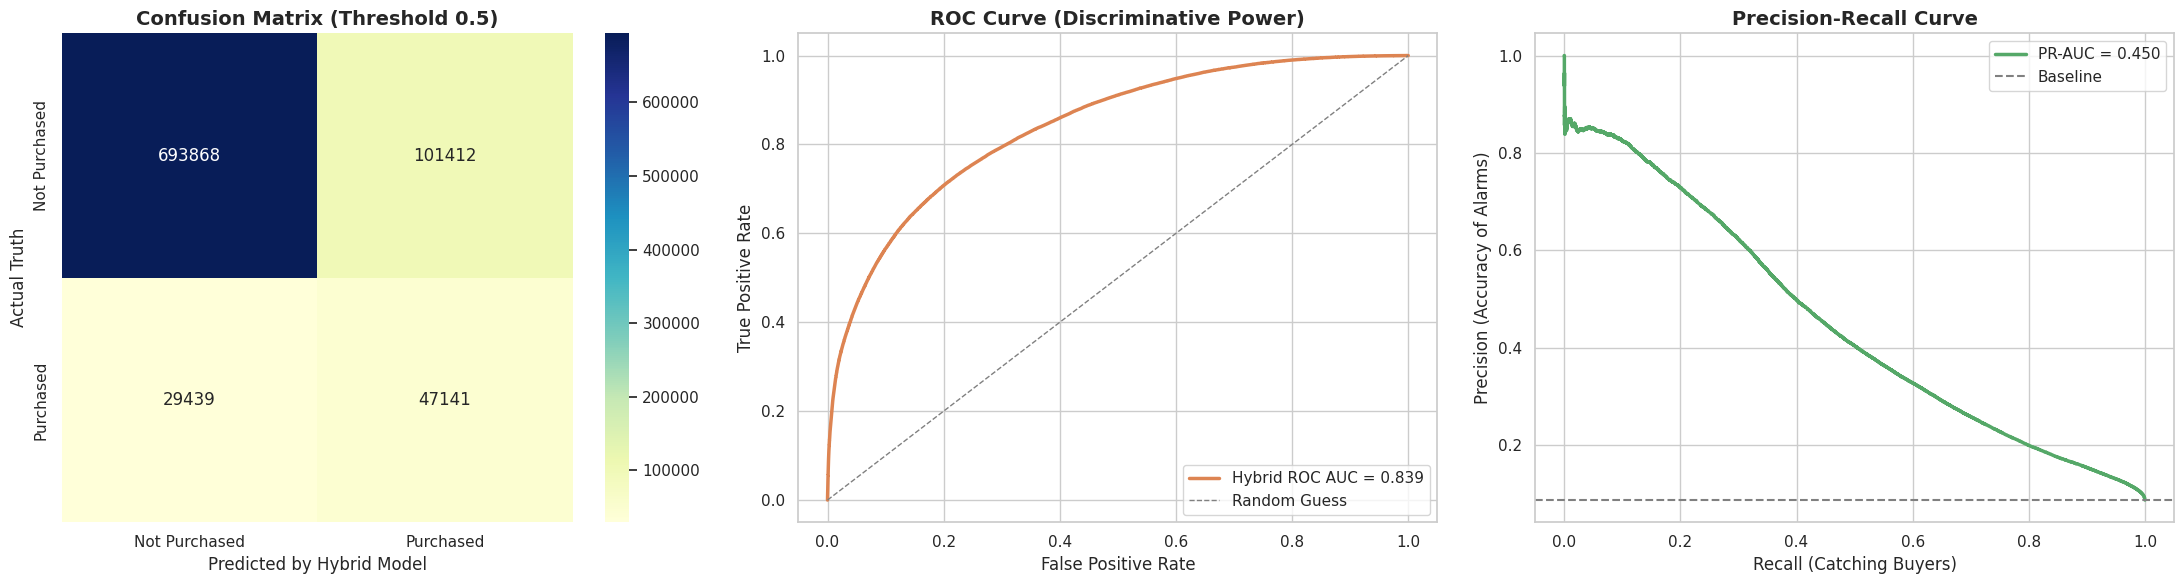


🧠 PHASE 5: HYBRID FEATURE IMPORTANCE (What won the fight?)
📊 Total Importance Share -> Tabular Features: 24.6% | GRU Embeddings: 75.4%



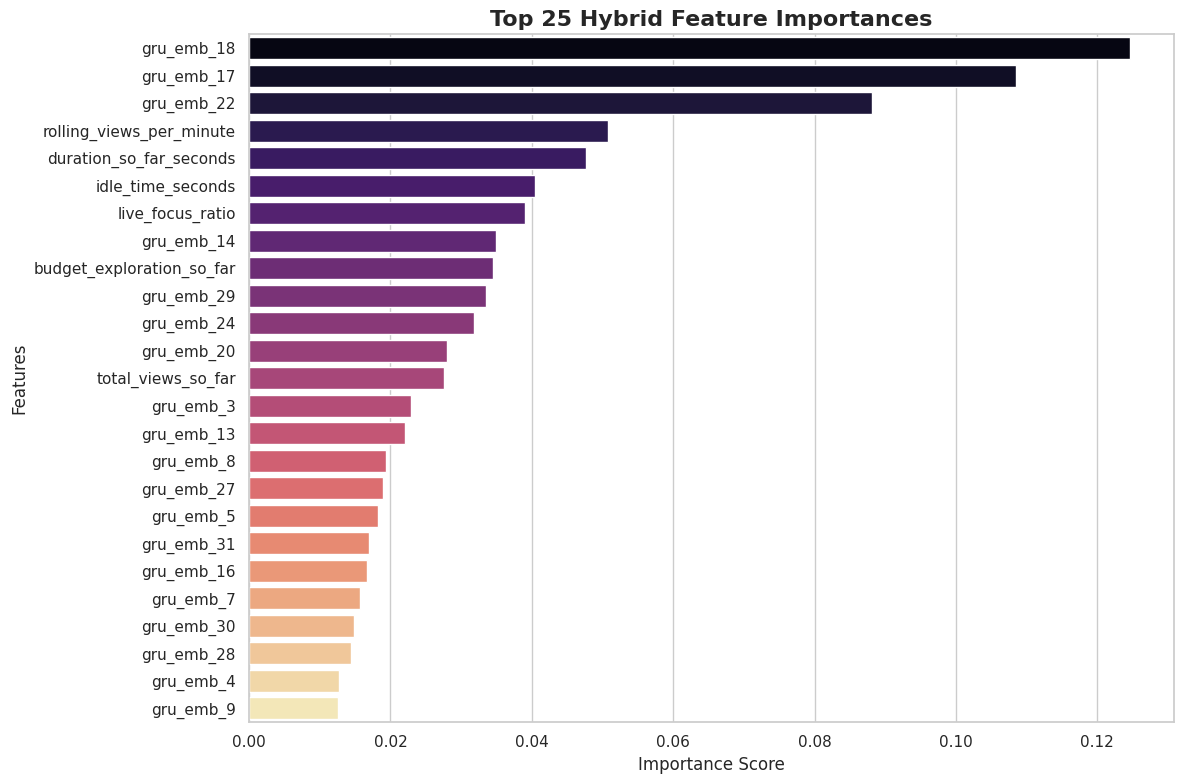

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, recall_score, f1_score,
    precision_score, roc_curve, auc, confusion_matrix,
    precision_recall_curve, average_precision_score, roc_auc_score
)
from IPython.display import display

print("=" * 70)
print("⚙️ PHASE 1: USER-BASED SPLIT FOR HYBRID DATA")
print("=" * 70)

# 1. Ensure No Leakage by Splitting on Users, not rows
unique_users = training_df['user_session'].unique()
train_users, test_users = train_test_split(unique_users, test_size=0.2, random_state=42)

train_data = training_df[training_df['user_session'].isin(train_users)].copy()
test_data  = training_df[training_df['user_session'].isin(test_users)].copy()

# 2. Separate Features and Target
# Drop columns that shouldn't be trained on
cols_to_drop = ['user_session', 'snapshot_label', 'target_purchase']
features = [col for col in training_df.columns if col not in cols_to_drop]

X_train = train_data[features]
y_train = train_data['target_purchase']
X_test  = test_data[features]
y_test  = test_data['target_purchase']

# 3. Calculate class imbalance weight
imbalance_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"✅ Total Features: {len(features)} (Tabular + GRU Embeddings)")
print(f"✅ Training Snapshots: {X_train.shape[0]:,}")
print(f"✅ Testing Snapshots : {X_test.shape[0]:,}")
print(f"✅ Class Weight Computed: {imbalance_weight:.2f}")


print("\n" + "=" * 70)
print("🚀 PHASE 2: TRAINING THE HYBRID XGBOOST")
print("=" * 70)

# Initializing a robust XGBoost Model with GPU support
hybrid_xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,                  # Keep tree depth moderate to balance tabular & deep features
    learning_rate=0.05,
    colsample_bytree=0.7,         # Forces model to mix GRU and Tabular features
    subsample=0.8,
    reg_alpha=0.5,                # L1 regularization to ignore useless GRU dimensions
    reg_lambda=2.0,               # L2 regularization
    scale_pos_weight=imbalance_weight * 0.7, # Slightly reduced to protect precision
    random_state=42,
    tree_method='hist',
    device='cuda',                # GPU Acceleration
    eval_metric='auc'
)

print("Training in progress... (Combining tabular logic with GRU intuition)")
hybrid_xgb.fit(X_train, y_train)
print("✅ Hybrid Model Trained Successfully!")


print("\n" + "=" * 70)
print("📈 PHASE 3: METRICS & CLASSIFICATION REPORT (Threshold = 0.5)")
print("=" * 70)

y_pred = hybrid_xgb.predict(X_test)
y_probs = hybrid_xgb.predict_proba(X_test)[:, 1]

print("📝 DETAILED CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['No Purchase', 'Purchase']))

print("\n🚀 CORE METRICS:")
print(f"-> Accuracy          : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"-> Recall   (Buyers) : {recall_score(y_test, y_pred)*100:.2f}%")
print(f"-> Precision(Buyers) : {precision_score(y_test, y_pred)*100:.2f}%")
print(f"-> F1-Score          : {f1_score(y_test, y_pred)*100:.2f}%")
print(f"-> ROC-AUC Score     : {roc_auc_score(y_test, y_probs):.4f}")
print(f"-> PR-AUC Score      : {average_precision_score(y_test, y_probs):.4f}")


print("\n" + "=" * 70)
print("🎨 PHASE 4: VISUALIZING THE PERFORMANCE")
print("=" * 70)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Graph 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Not Purchased', 'Purchased'],
            yticklabels=['Not Purchased', 'Purchased'], ax=axes[0])
axes[0].set_title('Confusion Matrix (Threshold 0.5)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted by Hybrid Model'); axes[0].set_ylabel('Actual Truth')

# Graph 2: ROC-AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#DD8452', lw=2.5, label=f'Hybrid ROC AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'gray', lw=1, linestyle='--', label='Random Guess')
axes[1].set_title('ROC Curve (Discriminative Power)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

# Graph 3: Precision-Recall Curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)
pr_auc = average_precision_score(y_test, y_probs)
axes[2].plot(recalls, precisions, color='#55A868', lw=2.5, label=f'PR-AUC = {pr_auc:.3f}')
axes[2].axhline(y=(y_test==1).mean(), color='gray', linestyle='--', label='Baseline')
axes[2].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Recall (Catching Buyers)'); axes[2].set_ylabel('Precision (Accuracy of Alarms)')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()


print("\n" + "=" * 70)
print("🧠 PHASE 5: HYBRID FEATURE IMPORTANCE (What won the fight?)")
print("=" * 70)

# Calculate feature importances
feat_imp = pd.Series(hybrid_xgb.feature_importances_, index=features).sort_values(ascending=False)

# Analyze Tabular vs GRU contribution
gru_cols = [col for col in features if 'gru_emb' in col]
tab_cols = [col for col in features if 'gru_emb' not in col]

gru_importance = feat_imp[gru_cols].sum() * 100
tab_importance = feat_imp[tab_cols].sum() * 100

print(f"📊 Total Importance Share -> Tabular Features: {tab_importance:.1f}% | GRU Embeddings: {gru_importance:.1f}%\n")

# Plot Top 25 Features
plt.figure(figsize=(12, 8))
top_n = 25
sns.barplot(x=feat_imp.head(top_n).values, y=feat_imp.head(top_n).index, palette='magma')
plt.title(f'Top {top_n} Hybrid Feature Importances', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

⚙️ PHASE 1: USER-BASED SPLIT FOR HYBRID DATA
✅ Total Features: 39 (Tabular + GRU Embeddings)
✅ Training Snapshots: 3,487,435
✅ Testing Snapshots : 871,860
✅ Class Weight Computed: 10.29

🚀 PHASE 2: ADVANCED HYPERPARAMETER TUNING (Group-Aware)
Starting Group-Aware CV Tuning (Trying 15 combinations)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [21:32:58] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END colsample_bytree=0.6, learning_rate=0.05, max_depth=4, n_estimators=300, reg_alpha=0.5, reg_lambda=5.0, scale_pos_weight=7.714374130287046, subsample=0.9; total time=  25.1s
[CV] END colsample_bytree=0.6, learning_rate=0.05, max_depth=4, n_estimators=300, reg_alpha=0.5, reg_lambda=5.0, scale_pos_weight=7.714374130287046, subsample=0.9; total time=  22.2s
[CV] END colsample_bytree=0.6, learning_rate=0.05, max_depth=4, n_estimators=300, reg_alpha=0.5, reg_lambda=5.0, scale_pos_weight=7.714374130287046, subsample=0.9; total time=  22.1s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=200, reg_alpha=0.5, reg_lambda=2.0, scale_pos_weight=10.285832173716061, subsample=0.9; total time=  21.2s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=200, reg_alpha=0.5, reg_lambda=2.0, scale_pos_weight=10.285832173716061, subsample=0.9; total time=  21.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=200, r

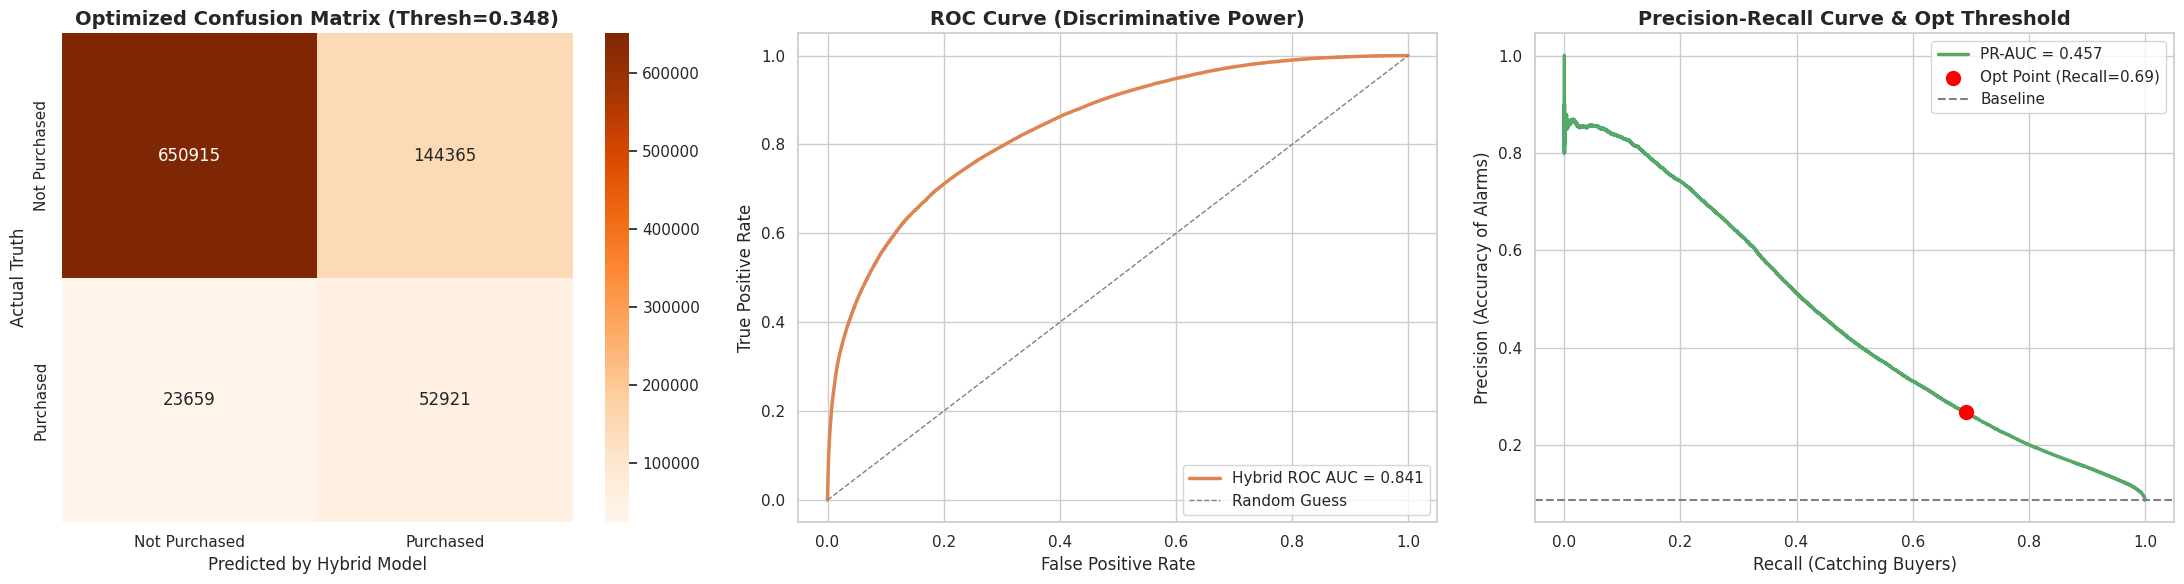


🧠 PHASE 6: HYBRID FEATURE IMPORTANCE
📊 Total Importance Share -> Tabular Features: 22.2% | GRU Embeddings: 77.8%



/tmp/ipykernel_50162/1073788237.py:181: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.head(top_n).values, y=feat_imp.head(top_n).index, palette='magma')


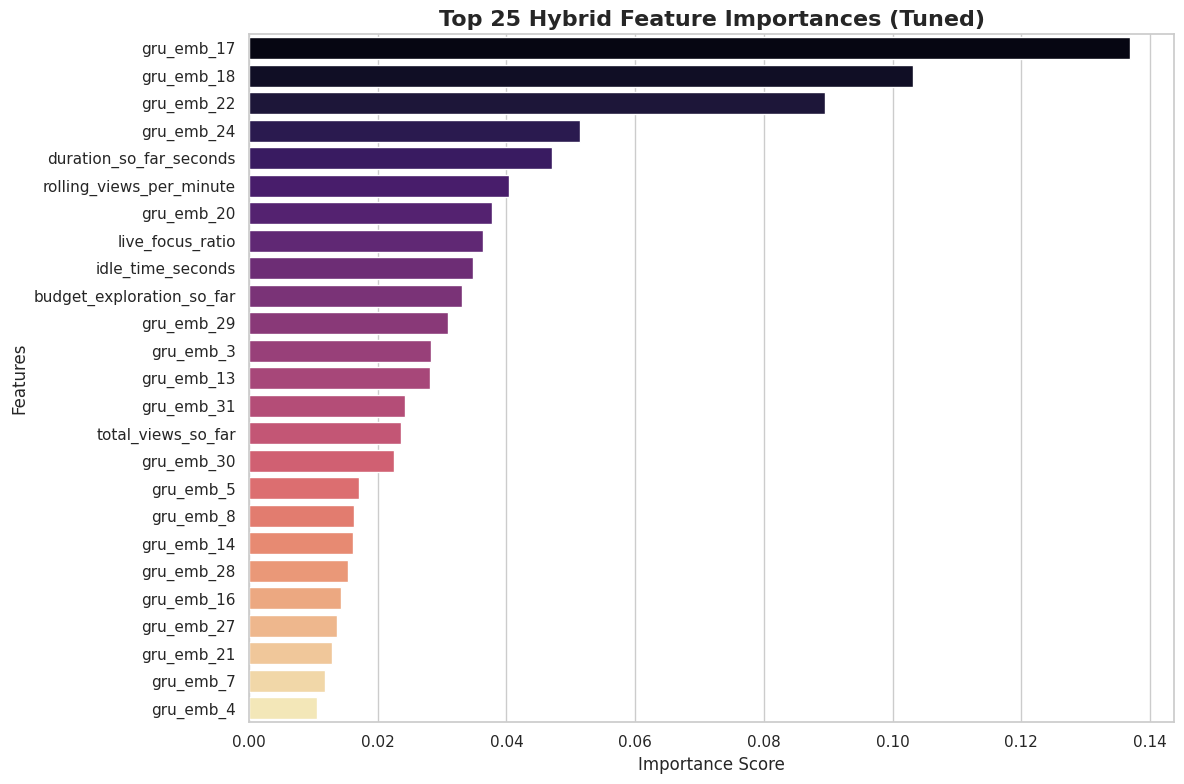

In [ ]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedGroupKFold
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, recall_score, f1_score,
    precision_score, roc_curve, auc, confusion_matrix,
    precision_recall_curve, average_precision_score, roc_auc_score
)
from IPython.display import display

print("=" * 70)
print("⚙️ PHASE 1: USER-BASED SPLIT FOR HYBRID DATA")
print("=" * 70)

unique_users = training_df['user_session'].unique()
train_users, test_users = train_test_split(unique_users, test_size=0.2, random_state=42)

train_data = training_df[training_df['user_session'].isin(train_users)].copy()
test_data  = training_df[training_df['user_session'].isin(test_users)].copy()

cols_to_drop = ['user_session', 'snapshot_label', 'target_purchase']
features = [col for col in training_df.columns if col not in cols_to_drop]

X_train = train_data[features]
y_train = train_data['target_purchase']
groups_train = train_data['user_session'] # 🌟 SUPER IMPORTANT FOR CV LEAKAGE PREVENTION

X_test  = test_data[features]
y_test  = test_data['target_purchase']

imbalance_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"✅ Total Features: {len(features)} (Tabular + GRU Embeddings)")
print(f"✅ Training Snapshots: {X_train.shape[0]:,}")
print(f"✅ Testing Snapshots : {X_test.shape[0]:,}")
print(f"✅ Class Weight Computed: {imbalance_weight:.2f}")


print("\n" + "=" * 70)
print("🚀 PHASE 2: ADVANCED HYPERPARAMETER TUNING (Group-Aware)")
print("=" * 70)

# The Search Space (Range of Hyperparameters)
param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'colsample_bytree': [0.6, 0.7, 0.8],  # Force mixing of GRU & Tabular
    'subsample': [0.7, 0.8, 0.9],
    'reg_alpha': [0.1, 0.5, 1.0],         # L1 Regularization
    'reg_lambda': [1.0, 2.0, 5.0],        # L2 Regularization
    'scale_pos_weight': [imbalance_weight * 0.5, imbalance_weight * 0.75, imbalance_weight]
}

# Leakage-Free CV
sgkf = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)

xgb_base = XGBClassifier(
    random_state=42,
    tree_method='hist',
    device='cuda',
    eval_metric='auc'
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=15,               # Adjust this based on how much time you have
    scoring='average_precision', # Optimize for PR-AUC to keep False Positives in check
    cv=sgkf,
    verbose=2,
    random_state=42,
    n_jobs=1
)

print(f"Starting Group-Aware CV Tuning (Trying {random_search.n_iter} combinations)...")
start_time = time.time()
random_search.fit(X_train, y_train, groups=groups_train)

print(f"\n✅ Tuning Completed in {(time.time() - start_time)/60:.2f} minutes!")
hybrid_xgb = random_search.best_estimator_
print(f"🏆 WINNING HYPERPARAMETERS:\n{random_search.best_params_}")


print("\n" + "=" * 70)
print("🎯 PHASE 3: OPTIMAL THRESHOLD DISCOVERY (Max Recall via F2-Score)")
print("=" * 70)

y_probs = hybrid_xgb.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Beta = 2 heavily penalizes False Negatives (Missed Buyers)
beta = 2
f2_scores = (1 + beta**2) * (precisions[:-1] * recalls[:-1]) / ((beta**2 * precisions[:-1]) + recalls[:-1])
f2_scores = np.nan_to_num(f2_scores)

optimal_idx = np.argmax(f2_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"✨ MATHEMATICALLY OPTIMAL THRESHOLD FOUND: {optimal_threshold:.4f}\n")

# Apply the new threshold
y_pred_optimal = (y_probs >= optimal_threshold).astype(int)


print("\n" + "=" * 70)
print("📈 PHASE 4: FINAL METRICS & CLASSIFICATION REPORT")
print("=" * 70)

print(f"📝 DETAILED CLASSIFICATION REPORT (Threshold = {optimal_threshold:.4f}):")
print(classification_report(y_test, y_pred_optimal, target_names=['No Purchase', 'Purchase']))

print("\n🚀 CORE METRICS:")
print(f"-> Accuracy          : {accuracy_score(y_test, y_pred_optimal)*100:.2f}%")
print(f"-> Recall   (Buyers) : {recall_score(y_test, y_pred_optimal)*100:.2f}%")
print(f"-> Precision(Buyers) : {precision_score(y_test, y_pred_optimal)*100:.2f}%")
print(f"-> F1-Score          : {f1_score(y_test, y_pred_optimal)*100:.2f}%")
print(f"-> F2-Score          : {f2_scores[optimal_idx]:.4f}")
print(f"-> ROC-AUC Score     : {roc_auc_score(y_test, y_probs):.4f}")
print(f"-> PR-AUC Score      : {average_precision_score(y_test, y_probs):.4f}")


print("\n" + "=" * 70)
print("🎨 PHASE 5: VISUALIZING THE PERFORMANCE")
print("=" * 70)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Graph 1: Optimized Confusion Matrix
cm = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Purchased', 'Purchased'],
            yticklabels=['Not Purchased', 'Purchased'], ax=axes[0])
axes[0].set_title(f'Optimized Confusion Matrix (Thresh={optimal_threshold:.3f})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted by Hybrid Model'); axes[0].set_ylabel('Actual Truth')

# Graph 2: ROC-AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#DD8452', lw=2.5, label=f'Hybrid ROC AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'gray', lw=1, linestyle='--', label='Random Guess')
axes[1].set_title('ROC Curve (Discriminative Power)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

# Graph 3: Precision-Recall Curve with Optimal Point
pr_auc = average_precision_score(y_test, y_probs)
axes[2].plot(recalls, precisions, color='#55A868', lw=2.5, label=f'PR-AUC = {pr_auc:.3f}')
axes[2].scatter(recalls[optimal_idx], precisions[optimal_idx], color='red', s=100, zorder=5,
                label=f'Opt Point (Recall={recalls[optimal_idx]:.2f})')
axes[2].axhline(y=(y_test==1).mean(), color='gray', linestyle='--', label='Baseline')
axes[2].set_title('Precision-Recall Curve & Opt Threshold', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Recall (Catching Buyers)'); axes[2].set_ylabel('Precision (Accuracy of Alarms)')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()


print("\n" + "=" * 70)
print("🧠 PHASE 6: HYBRID FEATURE IMPORTANCE")
print("=" * 70)

feat_imp = pd.Series(hybrid_xgb.feature_importances_, index=features).sort_values(ascending=False)

gru_cols = [col for col in features if 'gru_emb' in col]
tab_cols = [col for col in features if 'gru_emb' not in col]

gru_importance = feat_imp[gru_cols].sum() * 100
tab_importance = feat_imp[tab_cols].sum() * 100

print(f"📊 Total Importance Share -> Tabular Features: {tab_importance:.1f}% | GRU Embeddings: {gru_importance:.1f}%\n")

plt.figure(figsize=(12, 8))
top_n = 25
sns.barplot(x=feat_imp.head(top_n).values, y=feat_imp.head(top_n).index, palette='magma')
plt.title(f'Top {top_n} Hybrid Feature Importances (Tuned)', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import os
import pickle

print("💾 SAVING THE FINAL CHAMPION MODEL...")

# 1. Folder create karo jahan backend expect kar raha hai
MODEL_DIR = 'ml_models'
os.makedirs(MODEL_DIR, exist_ok=True)

# 2. Path define karo
xgb_model_path = os.path.join(MODEL_DIR, 'xgboost_hybrid.pkl')

# 3. Model ko Pickle format mein save karo
with open(xgb_model_path, 'wb') as f:
    pickle.dump(hybrid_xgb, f)

print(f"✅ Final Tuned XGBoost Model saved successfully at: {xgb_model_path}")
print("Ab is file ko seedha apne FastAPI backend mein load kar sakte ho!")

💾 SAVING THE FINAL CHAMPION MODEL...
✅ Final Tuned XGBoost Model saved successfully at: ml_models/xgboost_hybrid.pkl
Ab is file ko seedha apne FastAPI backend mein load kar sakte ho!
